In [3]:
from pathlib import Path

import earthkit 
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

In [4]:
temperature = earthkit.data.from_source(
    'cds',
    "derived-era5-pressure-levels-daily-statistics",
    {
        'product_type': 'reanalysis',
        'variable': ['temperature'],
        'year': '2023',
        'month': ['07'],
        'day': ['01'],
        'pressure_level': ['1000'],
        'daily_statistic': 'daily_mean',
        'time_zone': 'utc+00:00',
        'frequency': '1_hourly'
    },
)
datetime_for_plot = "2023-07-01 (UTC)"

2026-04-06 14:33:49,981 INFO Request ID is e43fdbd8-d5da-4c0d-aef5-630818add94f
2026-04-06 14:33:50,082 INFO status has been updated to accepted
2026-04-06 14:34:03,776 INFO status has been updated to running
2026-04-06 14:34:11,464 INFO status has been updated to successful


In [5]:
temperature = earthkit.data.from_source(
    'cds',
    "derived-era5-pressure-levels-daily-statistics",
    {
        'product_type': 'reanalysis',
        'variable': ['temperature'],
        'year': '2026',
        'month': ['03'],
        'day': ['01'],
        'pressure_level': ['1000'],
        'daily_statistic': 'daily_mean',
        'time_zone': 'utc+00:00',
        'frequency': '1_hourly'
    },
)
datetime_for_plot = "2026-03-01 (UTC)"

2026-04-06 14:34:21,745 INFO Request ID is 2d656f24-9dd4-4198-b58b-a7f0e0987a75
2026-04-06 14:34:21,855 INFO status has been updated to accepted
2026-04-06 14:34:36,399 INFO status has been updated to running
2026-04-06 14:34:55,603 INFO status has been updated to successful


In [6]:
temperature_style = earthkit.plots.styles.Style(
    colors="turbo",
    levels=range(-40, 41, 2),
    extend="both",
    units="celsius",
)

import cartopy.crs as ccrs

# Globe-like view focused on Africa.
crs = ccrs.Orthographic(central_longitude=20, central_latitude=5)

/tmp/ipykernel_112117/1954244481.py:9: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0.04, right=0.96, top=0.86, bottom=0.12)


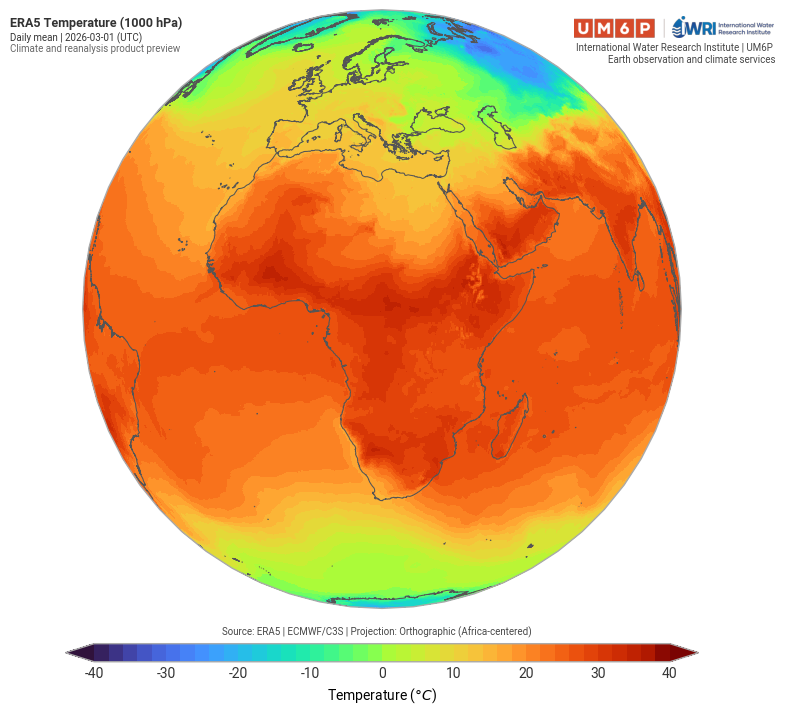

In [45]:
earthkit.plots.schema.figsize = (9, 8.5)

chart = earthkit.plots.Map(crs=crs)
chart.pcolormesh(temperature, style=temperature_style)
chart.coastlines(resolution="high")
chart.legend(location="bottom")

fig = plt.gcf()
fig.subplots_adjust(left=0.04, right=0.96, top=0.86, bottom=0.12)
repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "c3s_atlas").exists() and (path / "book").exists()
)
logo_path = repo_root / "book" / "customizing" / "data" / "logo" / "logo-um6p-iwri-transparent.png"

fig.text(
    0.035,
    0.985,
    "ERA5 Temperature (1000 hPa)",
    fontsize=9,
    fontweight="bold",
    ha="left",
    va="top",
)
fig.text(
    0.035,
    0.962,
    f"Daily mean | {datetime_for_plot}",
    fontsize=7,
    ha="left",
    va="top",
)
fig.text(
    0.3,
    0.1,
    "Source: ERA5 | ECMWF/C3S | Projection: Orthographic (Africa-centered)",
    fontsize=7,
    color="#444444",
    ha="left",
)
fig.text(
    0.035,
    0.945,
    "Climate and reanalysis product preview",
    fontsize=7,
    color="#666666",
    ha="left",
    va="top",
)

if logo_path.exists():
    logo = mpimg.imread(logo_path)
    ax_logo = fig.add_axes([0.74, 0.925, 0.25, 0.09])
    ax_logo.imshow(logo)
    ax_logo.axis("off")

fig.text(
    0.988,
    0.948,
    "International Water Research Institute | UM6P",
    fontsize=7,
    color="#444444",
    ha="right",
    va="top",
)
fig.text(
    0.992,
    0.93,
    "Earth observation and climate services",
    fontsize=7,
    color="#444444",
    ha="right",
    va="top",
)

#plt.savefig("overview-detail.png", dpi=200, bbox_inches="tight")
plt.show()